<a href="https://colab.research.google.com/github/ilyilayda/cv_pneumonia_detection/blob/main/comp_vision_term_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)

Kullanılan cihaz: cuda


In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "laydadinklah"
os.environ['KAGGLE_KEY'] = "KGAT_dd29b83a08fa26d2c3d5afb800090378"

In [ ]:
!pip install -q kaggle

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:15<00:00, 163MB/s]



In [ ]:
!unzip chest-xray-pneumonia.zip

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating: che

In [ ]:
import os
import shutil
import random

def create_small_dataset(src, dst, sample_size=200):
    os.makedirs(dst, exist_ok=True)

    for class_name in os.listdir(src):
        class_path = os.path.join(src, class_name)
        if not os.path.isdir(class_path):
            continue

        files = os.listdir(class_path)
        sampled = random.sample(files, min(sample_size, len(files)))

        os.makedirs(os.path.join(dst, class_name), exist_ok=True)

        for f in sampled:
            shutil.copy(os.path.join(class_path, f),
                        os.path.join(dst, class_name, f))

create_small_dataset("/content/chest_xray/train", "/content/small_train", 200)

In [ ]:
base_dir = "/content/chest_xray/chest_xray"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print("Train klasörü:", os.listdir(train_dir))
print("Validation klasörü:", os.listdir(val_dir))
print("Test klasörü:", os.listdir(test_dir))

Train klasörü: ['.DS_Store', 'PNEUMONIA', 'NORMAL']
Validation klasörü: ['.DS_Store', 'PNEUMONIA', 'NORMAL']
Test klasörü: ['.DS_Store', 'PNEUMONIA', 'NORMAL']


In [ ]:
#Görselleri modele uygun hale getirme
'''train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])'''

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
#Dataset ve DataLoader’ı oluştur
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train örnek sayısı:", len(train_dataset))
print("Validation örnek sayısı:", len(val_dataset))
print("Test örnek sayısı:", len(test_dataset))
print("Sınıflar:", train_dataset.classes)

Train örnek sayısı: 5216
Validation örnek sayısı: 16
Test örnek sayısı: 624
Sınıflar: ['NORMAL', 'PNEUMONIA']


In [ ]:
#Class counts ve class weights hesapla
from collections import Counter

train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

print("Class counts:", class_counts)
print("Class names:", train_dataset.classes)

num_samples = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = []
for i in range(num_classes):
    weight = num_samples / (num_classes * class_counts[i])
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class counts: Counter({1: 3875, 0: 1341})
Class names: ['NORMAL', 'PNEUMONIA']
Class weights: tensor([1.9448, 0.6730], device='cuda:0')


In [ ]:
#Birkaç örnek görüntü göster
def show_samples(dataset, num_images=6):
    plt.figure(figsize=(15, 8))

    for i in range(num_images):
        image, label = dataset[i]

        # Tensor -> numpy
        image = image.numpy()

        # (C, H, W) -> (H, W, C)
        image = np.transpose(image, (1, 2, 0))

        # Normalize geri alma
        image = (image * 0.5) + 0.5

        # 0-1 aralığında tut
        image = np.clip(image, 0, 1)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(dataset.classes[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

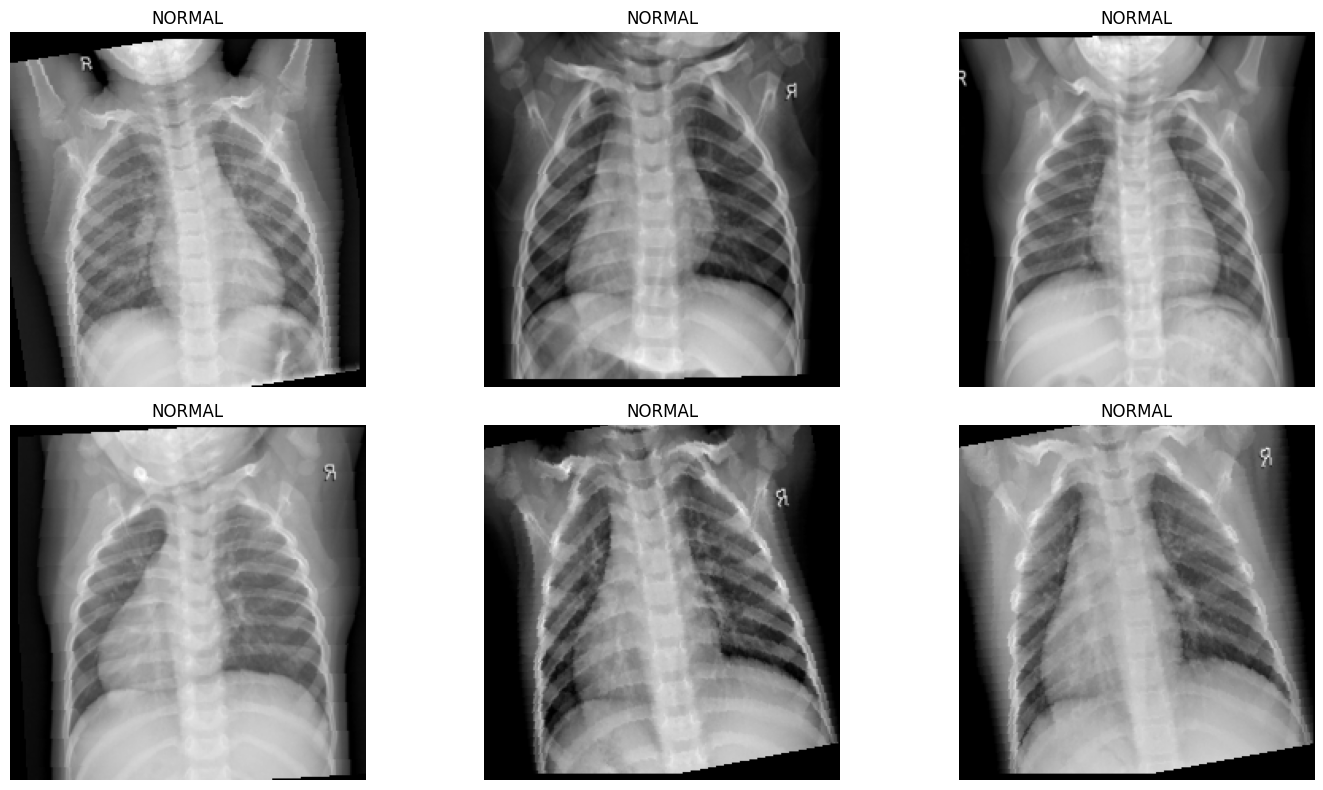

In [ ]:
show_samples(train_dataset, num_images=6)

In [ ]:
#Güncellenmiş model
class SimpleCNNImproved(nn.Module):
    def __init__(self):
        super(SimpleCNNImproved, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
sample_image, sample_label = train_dataset[0]
print("Görüntü boyutu:", sample_image.shape)

Görüntü boyutu: torch.Size([3, 224, 224])


In [ ]:
#Modeli oluştur
#model = SimpleCNN().to(device)
#print(model)

In [ ]:
#Model, weighted loss ve optimizer
model = SimpleCNNImproved().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print(model)

SimpleCNNImproved(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [ ]:
#Tek batch deneyelim
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Output shape: torch.Size([16, 2])
Labels shape: torch.Size([16])


In [ ]:
#Accuracy hesaplama fonksiyonu
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    acc = correct / total
    return acc

In [ ]:
#Training fonksiyonu
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train() #Modeli eğitim moduna geçirir. Dropout gibi katmanlar buna göre davranır.

    running_loss = 0.0
    running_acc = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() #Bir önceki batch’in gradientlerini temizler.

        outputs = model(images) #Görüntüleri modele verir, tahmin üretir.
        loss = criterion(outputs, labels) #Tahminle gerçek etiket arasındaki hatayı hesaplar.

        loss.backward() #Gradient hesaplar.
        optimizer.step() #Model ağırlıklarını günceller.

        acc = calculate_accuracy(outputs, labels)

        running_loss += loss.item()
        running_acc += acc

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [ ]:
#Validation fonksiyonu
def validate_one_epoch(model, loader, criterion, device):
    model.eval() #Model validation moduna geçer.

    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad(): #Bu aşamada gradient hesaplanmaz çünkü öğrenme yok. Bu hem daha hızlıdır hem de daha az bellek kullanır.
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            acc = calculate_accuracy(outputs, labels)

            running_loss += loss.item()
            running_acc += acc

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [ ]:
#Yeni modeli eğit ve en iyisini kaydet
best_val_acc = 0.0
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_simple_cnn_weighted.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

print("En iyi validation accuracy:", best_val_acc)

Epoch [1/10]
Train Loss: 0.3804 | Train Acc: 0.8246
Val Loss:   0.6983 | Val Acc:   0.7500
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.2064 | Train Acc: 0.9247
Val Loss:   0.6517 | Val Acc:   0.6875
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.1835 | Train Acc: 0.9321
Val Loss:   0.8390 | Val Acc:   0.5625
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.1685 | Train Acc: 0.9448
Val Loss:   0.7830 | Val Acc:   0.5625
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.1618 | Train Acc: 0.9436
Val Loss:   0.6801 | Val Acc:   0.5625
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.1606 | Train Acc: 0.9433
Val Loss:   0.4907 | Val Acc:   0.7500
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.1546 | Train Acc: 0.9454
Val Loss:   0.4039 | Val Acc:   0.8125
--------------------------------------------------
Epoch 

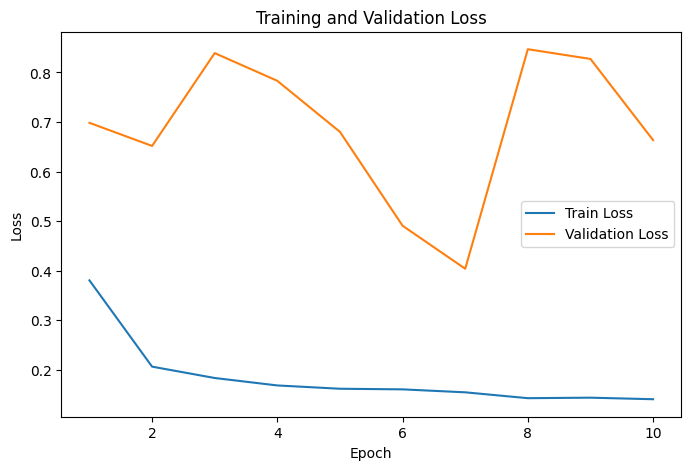

In [ ]:
#Loss grafiği çizme
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

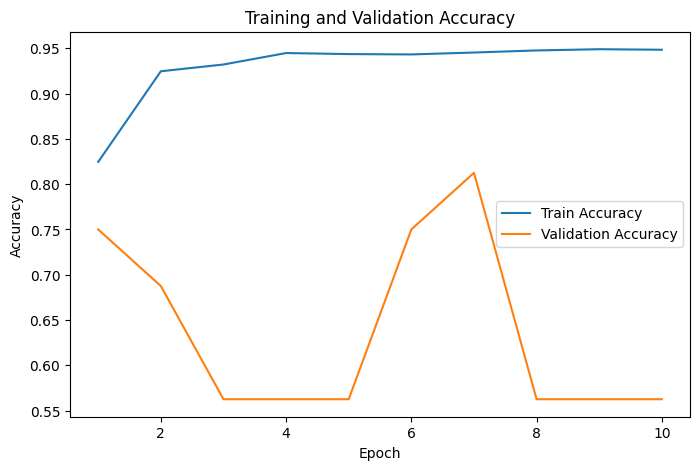

In [ ]:
#Accuracy grafiği çizme
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import seaborn as sns

In [ ]:
#Test değerlendirmesi için güncellenmiş model yükleme
best_model = SimpleCNNImproved().to(device)
best_model.load_state_dict(torch.load("best_simple_cnn_weighted.pth", map_location=device))
best_model.eval()

print("Improved model başarıyla yüklendi.")

Improved model başarıyla yüklendi.


In [ ]:
#Test set üzerinde tahmin toplama
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy()) #gerçek etiketler
        all_preds.extend(preds.cpu().numpy()) #modelin tahmin ettiği sınıflar
        all_probs.extend(probs[:, 1].cpu().numpy())  # pneumonia sınıfı olasılığı

In [ ]:
#Ana metrikleri hesapla
test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds)
test_recall = recall_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_probs)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_auc:.4f}")

In [ ]:
#Classification report al
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

In [ ]:
#Confusion matrix çıkar
cm = confusion_matrix(all_labels, all_preds)
print(cm)

Confusion matrix şöyle okunur:

* sol üst: normal doğru tahmin
* sağ üst: normal olup yanlış pneumonia denilen
* sol alt: pneumonia olup yanlış normal denilen
* sağ alt: pneumonia doğru tahmin



In [ ]:
#Confusion matrix görselleştir
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#ROC curve çiz
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
results = {
    "Accuracy": test_acc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
    "ROC-AUC": test_auc
}

print(results)